# 1. Importing Libraries

In [1]:
from dataclasses import dataclass
from itertools import combinations
from typing import Any

import math
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, pairwise_distances

# 2. Load Data

In [2]:
df = pd.read_csv("data_with_pca.csv")

# 3. Cluster Analysis

In [3]:
X_cluster = df[["PC1", "PC2"]].copy()

In [4]:
@dataclass
class ClusterConfig:
    cluster_range: tuple = (2, 5)
    algorithms: tuple = ("kmeans", "ward", "complete", "average")
    min_cluster_size: int = 50
    balance_weight: float = 0.25
    top_n: int = 10
    random_state: int = 42
    n_init: int = 20


def normalize(series, higher=True):
    if series.nunique() <= 1:
        return pd.Series(np.ones(len(series)))
    if higher:
        return (series - series.min()) / (series.max() - series.min())
    return (series.max() - series) / (series.max() - series.min())


def brute_force_cluster(X, config):
    results = []

    for k in range(config.cluster_range[0], config.cluster_range[1] + 1):
        for algo in config.algorithms:

            try:
                if algo == "kmeans":
                    model = KMeans(n_clusters=k, random_state=config.random_state, n_init=config.n_init)
                    labels = model.fit_predict(X)
                else:
                    model = AgglomerativeClustering(n_clusters=k, linkage=algo)
                    labels = model.fit_predict(X)
            except:
                continue

            if len(np.unique(labels)) < 2:
                continue

            counts = pd.Series(labels).value_counts()
            min_size = counts.min()
            max_size = counts.max()

            if min_size < config.min_cluster_size:
                continue

            try:
                sil = silhouette_score(X, labels)
                cal = calinski_harabasz_score(X, labels)
                dav = davies_bouldin_score(X, labels)
            except:
                continue

            balance = min_size / max_size

            results.append({
                "algorithm": algo,
                "k": k,
                "silhouette": sil,
                "calinski": cal,
                "davies": dav,
                "balance": balance,
                "labels": labels
            })

    df = pd.DataFrame(results)

    df["sil_n"] = normalize(df["silhouette"], True)
    df["cal_n"] = normalize(df["calinski"], True)
    df["dav_n"] = normalize(df["davies"], False)
    df["bal_n"] = normalize(df["balance"], True)

    df["score"] = (
        0.4 * df["sil_n"] +
        0.25 * df["cal_n"] +
        0.2 * df["dav_n"] +
        config.balance_weight * df["bal_n"]
    )

    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    return df.head(config.top_n), results

In [5]:
config = ClusterConfig(
    cluster_range=(3, 4),
    min_cluster_size=80,
    top_n=10
)

summary, results = brute_force_cluster(X_cluster, config)

In [6]:
best = summary.iloc[0]

print("\nBest model:")
print(best)

df["Cluster"] = best["labels"]


Best model:
algorithm                                                kmeans
k                                                             3
silhouette                                             0.453017
calinski                                            3140.449228
davies                                                 0.810037
balance                                                0.710112
labels        [0, 1, 0, 1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 1, 0, ...
sil_n                                                       1.0
cal_n                                                       1.0
dav_n                                                       1.0
bal_n                                                       1.0
score                                                       1.1
Name: 0, dtype: object


In [7]:
cluster_fit_table = pd.DataFrame(
    [
        {
            "Clusters": int(best["k"]),
            "N": int(len(X_cluster)),
            "Silhouette": float(best["silhouette"]),
            "Calinski-Harabasz": float(best["calinski"]),
            "Davies-Bouldin": float(best["davies"]),
            "Balance": float(best["balance"]),
            "Algorithm": str(best["algorithm"]),
            "Score": float(best["score"]),
        }
    ]
)

display(cluster_fit_table)

,Clusters,N,Silhouette,Calinski-Harabasz,Davies-Bouldin,Balance,Algorithm,Score
0,3,2208,0.453017,3140.449228,0.810037,0.710112,kmeans,1.1


In [8]:
def compute_cluster_fit_table(X: pd.DataFrame | np.ndarray, labels: np.ndarray) -> pd.DataFrame:
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    n, p = X.shape
    k = len(unique_labels)

    grand_mean = X.mean(axis=0)
    tss = float(((X - grand_mean) ** 2).sum())

    wss = 0.0
    for cluster_id in unique_labels:
        cluster_points = X[labels == cluster_id]
        cluster_mean = cluster_points.mean(axis=0)
        wss += float(((cluster_points - cluster_mean) ** 2).sum())

    bss = tss - wss
    r2 = bss / tss if tss > 0 else np.nan

    sil = silhouette_score(X, labels)

    # Pseudo log-likelihood for hard clustering under spherical Gaussian error.
    sigma2 = max(wss / (n * p), 1e-12)
    log_likelihood = -0.5 * n * p * (np.log(2 * np.pi * sigma2) + 1)

    # Parameters: centroids + mixing proportions + shared variance
    n_params = k * p + (k - 1) + 1
    aic = 2 * n_params - 2 * log_likelihood
    bic = n_params * np.log(n) - 2 * log_likelihood

    return pd.DataFrame(
        [
            {
                "Clusters": int(k),
                "N": int(n),
                "R²": float(r2),
                "AIC": float(aic),
                "BIC": float(bic),
                "Silhouette": float(sil),
            }
        ]
    )


cluster_fit_table = compute_cluster_fit_table(X_cluster, best["labels"])

styled_cluster_fit_table = (
    cluster_fit_table.style
    .hide(axis="index")
    .format(
        {
            "Clusters": "{:.0f}",
            "N": "{:.0f}",
            "R²": "{:.3f}",
            "AIC": "{:.0f}",
            "BIC": "{:.0f}",
            "Silhouette": "{:.3f}",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("margin", "0"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "18px"),
                    ("border-top", "3px solid black"),
                    ("border-bottom", "3px solid black"),
                ],
            },
            {
                "selector": "thead th",
                "props": [
                    ("font-weight", "normal"),
                    ("text-align", "center"),
                    ("padding", "8px 18px"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "tbody td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "10px 18px"),
                ],
            },
        ]
    )
)

display(styled_cluster_fit_table)

Clusters,N,R²,AIC,BIC,Silhouette
3,2208,0.740,12435,12486,0.453


In [9]:
def compute_cluster_detail_table(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> pd.DataFrame:
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)

    unique_labels = np.sort(np.unique(labels))
    sil_samples = silhouette_samples(X, labels)

    cluster_sizes = {}
    cluster_wss = {}
    cluster_silhouette = {}

    for cluster_id in unique_labels:
        mask = labels == cluster_id
        X_k = X[mask]
        centroid_k = X_k.mean(axis=0)

        cluster_sizes[int(cluster_id)] = int(mask.sum())
        cluster_wss[int(cluster_id)] = float(((X_k - centroid_k) ** 2).sum())
        cluster_silhouette[int(cluster_id)] = float(sil_samples[mask].mean())

    total_wss = sum(cluster_wss.values())
    cluster_heterogeneity_prop = {
        k: (v / total_wss if total_wss > 0 else np.nan)
        for k, v in cluster_wss.items()
    }

    display_labels = [str(i + 1) for i in range(len(unique_labels))]
    label_map = {disp: int(cluster_id) for disp, cluster_id in zip(display_labels, unique_labels)}

    table = pd.DataFrame(
        {
            disp: {
                "Size": cluster_sizes[label_map[disp]],
                "Explained proportion\nwithin-cluster\nheterogeneity": cluster_heterogeneity_prop[label_map[disp]],
                "Within sum of\nsquares": cluster_wss[label_map[disp]],
                "Silhouette\nscore": cluster_silhouette[label_map[disp]],
            }
            for disp in display_labels
        }
    )

    table.index.name = "Cluster"
    return table


def format_cluster_detail_table_for_display(table: pd.DataFrame) -> pd.DataFrame:
    formatted = table.copy().astype(object)

    for row_name in formatted.index:
        if row_name == "Size":
            formatted.loc[row_name] = formatted.loc[row_name].map(lambda x: f"{x:.0f}")
        elif row_name == "Within sum of\nsquares":
            formatted.loc[row_name] = formatted.loc[row_name].map(lambda x: f"{x:.1f}")
        else:
            formatted.loc[row_name] = formatted.loc[row_name].map(lambda x: f"{x:.3f}")

    return formatted


cluster_detail_table = compute_cluster_detail_table(X_cluster, best["labels"])
cluster_detail_table_display = format_cluster_detail_table_for_display(cluster_detail_table)

styled_cluster_detail_table = (
    cluster_detail_table_display.style
    .set_table_styles(
        [
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "16px"),
                    ("border-top", "2px solid black"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "thead th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "normal"),
                    ("padding", "6px 14px"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "tbody th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "normal"),
                    ("padding", "6px 14px"),
                ],
            },
            {
                "selector": "tbody td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "6px 14px"),
                ],
            },
        ]
    )
)

display(styled_cluster_detail_table)

,1,2,3
Cluster,,,
Size,632,890,686
Explained proportion within-cluster heterogeneity,0.272,0.402,0.325
Within sum of squares,1172.0,1730.1,1400.0
Silhouette score,0.465,0.520,0.355


In [10]:
def infer_distance_metric(best_model: pd.Series | dict) -> str:
    if isinstance(best_model, pd.Series):
        best_model = best_model.to_dict()

    if "metric" in best_model and pd.notna(best_model["metric"]):
        return str(best_model["metric"])
    if "affinity" in best_model and pd.notna(best_model["affinity"]):
        return str(best_model["affinity"])

    algorithm = str(best_model.get("algorithm", "")).lower()

    # In your notebook:
    # - KMeans uses Euclidean distance
    # - AgglomerativeClustering was created without metric/affinity,
    #   so sklearn defaulted to Euclidean for the fitted model
    if algorithm in {"kmeans", "ward", "complete", "average"}:
        return "euclidean"

    return "euclidean"


def pearson_gamma_from_distances(dist_matrix: np.ndarray, labels: np.ndarray) -> float:
    n = len(labels)
    iu = np.triu_indices(n, k=1)

    d = dist_matrix[iu]
    between = (labels[iu[0]] != labels[iu[1]]).astype(float)

    if np.std(d) == 0 or np.std(between) == 0:
        return np.nan

    return float(np.corrcoef(d, between)[0, 1])


def compute_model_performance_metrics(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
    metric: str,
) -> pd.DataFrame:
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    unique_labels = np.sort(np.unique(labels))

    dist_matrix = pairwise_distances(X, metric=metric)

    max_diameter = 0.0
    min_separation = np.inf

    for cluster_id in unique_labels:
        idx = np.where(labels == cluster_id)[0]
        if len(idx) >= 2:
            within = dist_matrix[np.ix_(idx, idx)]
            diameter = float(np.max(within))
            max_diameter = max(max_diameter, diameter)

    for i, cluster_i in enumerate(unique_labels):
        idx_i = np.where(labels == cluster_i)[0]
        for cluster_j in unique_labels[i + 1:]:
            idx_j = np.where(labels == cluster_j)[0]
            between = dist_matrix[np.ix_(idx_i, idx_j)]
            separation = float(np.min(between))
            min_separation = min(min_separation, separation)

    dunn_index = (
        float(min_separation / max_diameter)
        if max_diameter > 0 and np.isfinite(min_separation)
        else np.nan
    )

    counts = np.array([(labels == cluster_id).sum() for cluster_id in unique_labels], dtype=float)
    proportions = counts / counts.sum()
    entropy = float(-(proportions * np.log(proportions)).sum())

    pearsons_gamma = pearson_gamma_from_distances(dist_matrix, labels)
    calinski = float(calinski_harabasz_score(X, labels))

    return pd.DataFrame(
        {
            "Value": [
                max_diameter,
                min_separation,
                pearsons_gamma,
                dunn_index,
                entropy,
                calinski,
            ]
        },
        index=[
            "Maximum\ndiameter",
            "Minimum\nseparation",
            "Pearson's\nγ",
            "Dunn index",
            "Entropy",
            "Calinski-\nHarabasz\nindex",
        ],
    )


def format_model_performance_table_for_display(table: pd.DataFrame) -> pd.DataFrame:
    formatted = table.copy().astype(object)

    for row_name in formatted.index:
        value = table.loc[row_name, "Value"]

        if row_name == "Calinski-\nHarabasz\nindex":
            formatted.loc[row_name, "Value"] = f"{value:.0f}"
        else:
            formatted.loc[row_name, "Value"] = f"{value:.3f}"

    return formatted


metric_used = infer_distance_metric(best)
model_performance_table = compute_model_performance_metrics(
    X=X_cluster,
    labels=best["labels"],
    metric=metric_used,
)
model_performance_table_display = format_model_performance_table_for_display(model_performance_table)

print(f"Distance metric used for this table: {metric_used}")

styled_model_performance_table = (
    model_performance_table_display.style
    .set_caption("Model Performance Metrics")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-style", "italic"),
                    ("font-size", "18px"),
                    ("padding-bottom", "8px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "16px"),
                    ("border-top", "2px solid black"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "thead th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "normal"),
                    ("padding", "4px 16px"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "tbody th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "normal"),
                    ("padding", "6px 16px"),
                ],
            },
            {
                "selector": "tbody td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "6px 16px"),
                ],
            },
        ]
    )
)

display(styled_model_performance_table)

print(f"Note. All metrics are based on the {metric_used} distance.")

Distance metric used for this table: euclidean


,Value
Maximum diameter,8.271
Minimum separation,0.052
Pearson's γ,0.660
Dunn index,0.006
Entropy,1.087
Calinski- Harabasz index,3140


Note. All metrics are based on the euclidean distance.


In [11]:
def compute_cluster_means_table(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        X_df = X.copy()
    else:
        X = np.asarray(X, dtype=float)
        X_df = pd.DataFrame(X, columns=[f"PC_{i + 1}" for i in range(X.shape[1])])

    labels = np.asarray(labels)
    cluster_order = np.sort(np.unique(labels))

    cluster_means = (
        X_df.assign(Cluster=labels)
        .groupby("Cluster", sort=True)
        .mean()
        .reindex(cluster_order)
    )

    cluster_means.index = [f"Cluster\n{i + 1}" for i in range(len(cluster_means.index))]
    cluster_means.index.name = ""

    return cluster_means


def format_cluster_means_table_for_display(table: pd.DataFrame) -> pd.DataFrame:
    formatted = table.copy().astype(object)
    for col in formatted.columns:
        formatted[col] = formatted[col].map(lambda x: f"{x:.3f}")
    return formatted


cluster_means_table = compute_cluster_means_table(X_cluster, best["labels"])
cluster_means_table_display = format_cluster_means_table_for_display(cluster_means_table)

styled_cluster_means_table = (
    cluster_means_table_display.style
    .set_caption("Cluster Means")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-style", "italic"),
                    ("font-size", "18px"),
                    ("padding-bottom", "8px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "16px"),
                    ("border-top", "2px solid black"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "thead th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "normal"),
                    ("padding", "6px 16px"),
                    ("border-bottom", "2px solid black"),
                ],
            },
            {
                "selector": "tbody th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "normal"),
                    ("padding", "6px 16px"),
                ],
            },
            {
                "selector": "tbody td",
                "props": [
                    ("text-align", "center"),
                    ("padding", "6px 16px"),
                ],
            },
        ]
    )
)

display(styled_cluster_means_table)

,PC1,PC2
,,
Cluster 1,2.808,-0.814
Cluster 2,-2.468,-0.374
Cluster 3,0.615,1.235


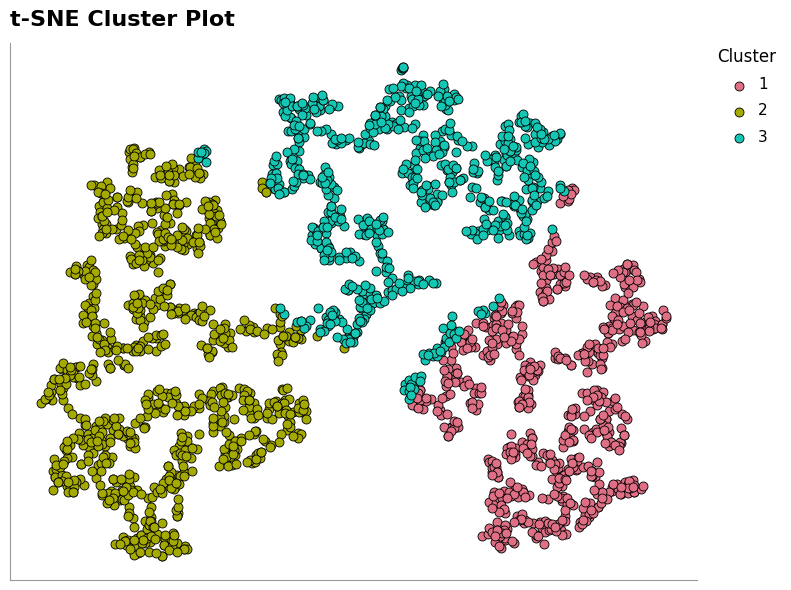

In [12]:
def plot_tsne_clusters(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
    perplexity: float = 30,
    random_state: int = 42,
    figsize: tuple[float, float] = (8, 6),
) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        X_values = X.values
    else:
        X_values = np.asarray(X, dtype=float)

    labels = np.asarray(labels)
    unique_labels = np.sort(np.unique(labels))
    display_map = {cluster_id: i + 1 for i, cluster_id in enumerate(unique_labels)}
    display_labels = np.array([display_map[label] for label in labels])

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate=200,
        max_iter=1000,
    )
    embedding = tsne.fit_transform(X_values)

    plot_df = pd.DataFrame(
        {
            "tSNE_1": embedding[:, 0],
            "tSNE_2": embedding[:, 1],
            "Cluster": display_labels,
        }
    )

    colors = ["#df6f85", "#a5aa00", "#14c7b5", "#8f84e8", "#f39c34", "#5dade2"]

    fig, ax = plt.subplots(figsize=figsize)

    for i, cluster_num in enumerate(sorted(plot_df["Cluster"].unique())):
        subset = plot_df[plot_df["Cluster"] == cluster_num]
        ax.scatter(
            subset["tSNE_1"],
            subset["tSNE_2"],
            s=42,
            c=colors[i % len(colors)],
            edgecolors="black",
            linewidths=0.6,
            alpha=1.0,
            label=str(cluster_num),
        )

    ax.set_title("t-SNE Cluster Plot", fontsize=16, fontweight="bold", loc="left", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#999999")
    ax.spines["bottom"].set_color("#999999")

    legend = ax.legend(
        title="Cluster",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        handletextpad=0.4,
        labelspacing=0.8,
    )
    legend.get_title().set_fontsize(12)
    for text in legend.get_texts():
        text.set_fontsize(11)

    plt.tight_layout()
    plt.show()

    return plot_df


tsne_plot_data = plot_tsne_clusters(
    X=X_cluster,
    labels=best["labels"],
    perplexity=30,
    random_state=42,
    figsize=(8, 6),
)

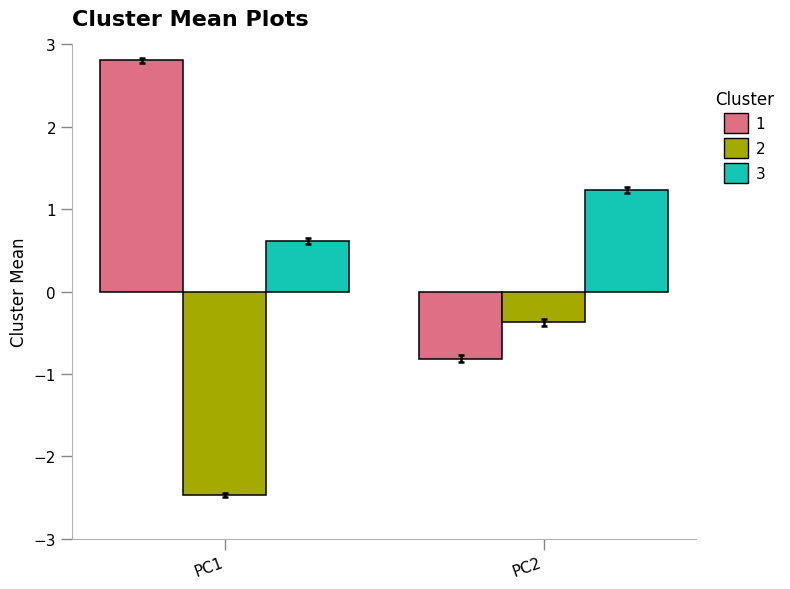

In [13]:
def prepare_cluster_mean_plot_data(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if isinstance(X, pd.DataFrame):
        X_df = X.copy()
    else:
        X = np.asarray(X, dtype=float)
        X_df = pd.DataFrame(X, columns=[f"PC_{i + 1}" for i in range(X.shape[1])])

    labels = np.asarray(labels)
    unique_labels = np.sort(np.unique(labels))
    cluster_map = {cluster_id: i + 1 for i, cluster_id in enumerate(unique_labels)}
    display_labels = np.array([cluster_map[label] for label in labels])

    plot_df = X_df.copy()
    plot_df["Cluster"] = display_labels

    means = plot_df.groupby("Cluster").mean()
    ses = plot_df.groupby("Cluster").sem()

    return means, ses


def plot_cluster_mean_bars(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
    figsize: tuple[float, float] = (8, 6),
) -> None:
    means, ses = prepare_cluster_mean_plot_data(X, labels)

    feature_names = list(means.columns)
    cluster_ids = list(means.index)
    n_features = len(feature_names)
    n_clusters = len(cluster_ids)

    colors = {
        1: "#df6f85",
        2: "#a5aa00",
        3: "#14c7b5",
        4: "#8f84e8",
        5: "#f39c34",
        6: "#5dade2",
    }

    x = np.arange(n_features)
    total_width = 0.78
    bar_width = total_width / n_clusters
    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
        total_width / 2 - bar_width / 2,
        n_clusters,
    )

    fig, ax = plt.subplots(figsize=figsize)

    for i, cluster_id in enumerate(cluster_ids):
        y = means.loc[cluster_id, feature_names].values
        yerr = ses.loc[cluster_id, feature_names].values

        ax.bar(
            x + offsets[i],
            y,
            width=bar_width,
            color=colors.get(cluster_id, "#999999"),
            edgecolor="black",
            linewidth=1.1,
            yerr=yerr,
            capsize=2.5,
            error_kw={"elinewidth": 1.8, "capthick": 1.8},
            label=str(cluster_id),
        )

    ax.set_title("Cluster Mean Plots", fontsize=16, fontweight="bold", loc="left", pad=14)

    ax.set_ylabel("Cluster Mean", fontsize=12)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(feature_names, rotation=20, ha="right", fontsize=11)

    y_min = min(-1, float(np.floor((means - ses).min().min())))
    y_max = max(1, float(np.ceil((means + ses).max().max())))
    ax.set_ylim(y_min, y_max)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#b0b0b0")
    ax.spines["bottom"].set_color("#b0b0b0")
    ax.tick_params(axis="both", length=8, width=1, color="#888888", labelsize=11)

    legend_handles = [
        Patch(
            facecolor=colors.get(cluster_id, "#999999"),
            edgecolor="black",
            label=str(cluster_id),
        )
        for cluster_id in cluster_ids
    ]

    legend = ax.legend(
        handles=legend_handles,
        title="Cluster",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.92),
        borderaxespad=0,
        handlelength=1.6,
        handleheight=1.6,
        handletextpad=0.5,
        labelspacing=0.35,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()
    plt.show()


plot_cluster_mean_bars(
    X=X_cluster,
    labels=best["labels"],
    figsize=(8, 6),
)

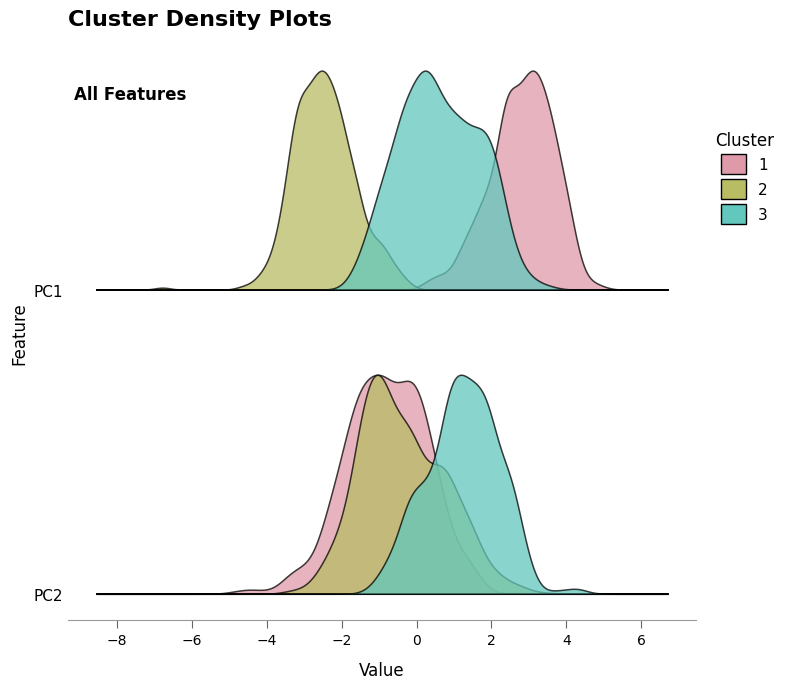

In [14]:
def plot_cluster_density_ridges(
    X: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
    figsize: tuple[float, float] = (8, 7),
    title: str = "Cluster Density Plots",
    subtitle: str = "All Features",
) -> None:
    if isinstance(X, pd.DataFrame):
        X_df = X.copy()
    else:
        X = np.asarray(X, dtype=float)
        X_df = pd.DataFrame(X, columns=[f"PC_{i + 1}" for i in range(X.shape[1])])

    labels = np.asarray(labels)
    unique_labels = np.sort(np.unique(labels))
    cluster_map = {cluster_id: i + 1 for i, cluster_id in enumerate(unique_labels)}
    display_labels = np.array([cluster_map[label] for label in labels])

    plot_df = X_df.copy()
    plot_df["Cluster"] = display_labels

    feature_names = list(X_df.columns)
    n_features = len(feature_names)

    colors = {
        1: "#df9aa9",
        2: "#b8bc63",
        3: "#62c8bd",
        4: "#a79ae3",
        5: "#f3b562",
        6: "#7cb5ec",
    }

    global_min = float(X_df.min().min())
    global_max = float(X_df.max().max())
    x_pad = 0.15 * (global_max - global_min if global_max > global_min else 1.0)
    x_grid = np.linspace(global_min - x_pad, global_max + x_pad, 500)

    fig, ax = plt.subplots(figsize=figsize)

    y_positions = np.arange(n_features, 0, -1)
    ridge_height = 0.72

    for y_pos, feature in zip(y_positions, feature_names):
        ax.hlines(y=y_pos, xmin=x_grid.min(), xmax=x_grid.max(), color="black", linewidth=1.1, zorder=1)

        for cluster_num in sorted(np.unique(display_labels)):
            values = plot_df.loc[plot_df["Cluster"] == cluster_num, feature].dropna().to_numpy()

            if len(values) == 0:
                continue

            if len(np.unique(values)) < 2 or np.std(values) < 1e-8:
                mu = float(np.mean(values))
                sigma = 0.08 if np.std(values) < 1e-8 else float(np.std(values))
                density = np.exp(-0.5 * ((x_grid - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
            else:
                kde = gaussian_kde(values)
                density = kde(x_grid)

            density = density / density.max() * ridge_height

            ax.fill_between(
                x_grid,
                y_pos,
                y_pos + density,
                color=colors.get(cluster_num, "#999999"),
                alpha=0.75,
                edgecolor="black",
                linewidth=1.1,
                zorder=2,
            )

    ax.set_title(title, fontsize=16, fontweight="bold", loc="left", pad=14)
    ax.text(
        0.01,
        0.93,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )

    ax.set_xlabel("Value", fontsize=12, labelpad=10)
    ax.set_ylabel("Feature", fontsize=12)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(feature_names, fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#999999")

    ax.tick_params(axis="x", length=6, color="#666666")
    ax.tick_params(axis="y", length=0)

    legend_handles = [
        Patch(facecolor=colors.get(cluster_num, "#999999"), edgecolor="black", label=str(cluster_num))
        for cluster_num in sorted(np.unique(display_labels))
    ]

    ax.legend(
        handles=legend_handles,
        title="Cluster",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.86),
        borderaxespad=0,
        fontsize=11,
        title_fontsize=12,
        handlelength=1.6,
        handleheight=1.6,
        labelspacing=0.35,
    )

    plt.tight_layout()
    plt.show()


plot_cluster_density_ridges(
    X=X_cluster,
    labels=best["labels"],
    figsize=(8, 7),
)

In [15]:
cluster_share_table = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Proportion")
)

cluster_share_table["Cluster"] = range(1, len(cluster_share_table) + 1)

cluster_share_table

,Cluster,Proportion
0,1,0.286232
1,2,0.403080
2,3,0.310688


In [16]:
df_final = df.copy()
df_final["Cluster"] = best["labels"] + 1

df_final.to_csv("customer_segments.csv", index=False)

print(df_final[["Cluster"]].head())
print(df_final["Cluster"].value_counts().sort_index())

   Cluster
0        1
1        2
2        1
3        2
4        3
Cluster
1    632
2    890
3    686
Name: count, dtype: int64
